In [1]:
import wave
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Union
import matplotlib
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
from pydub import AudioSegment
import pandas as pd

In [2]:
DATASET_NAME = [
    'Pitt',
    'ADReSS',
    'Lu']

BASE_DIR = Path('../ad_detection/data/raw')

In [3]:
def get_audio_duration(audio_path: str) -> float:
    if audio_path.endswith('.wav'):
        with wave.open(audio_path, 'r') as wav_file:
            return wav_file.getnframes() / wav_file.getframerate()
    else:  # mp3
        audio = AudioSegment.from_mp3(audio_path)
        return len(audio) / 1000.0


def analyze_dataset(dataset_path: Path):
    durations = []
    class_counts = {'Control': 0, 'Dementia': 0}
    
    for subdir in ['Control', 'Dementia']:
        for file_path in (dataset_path / subdir).glob('*.[wm][ap][v3]'):
            durations.append(get_audio_duration(str(file_path)))
            class_counts[subdir] += 1
    
    return {'durations': durations, 'class_counts': class_counts}


def print_statistics(dataset_name: str, durations: List[float]):
    print(f"\n==============Dataset: {dataset_name}==============")
    print(f"File count: {len(durations)}")
    print(f"Max duration: {max(durations):.2f} sec")
    print(f"Min duration: {min(durations):.2f} sec")
    print(f"Mean duration: {np.mean(durations):.2f} sec")
    print(f"Median duration: {np.median(durations):.2f} sec")
    print(f"Total duration: {sum(durations)/60:.2f} min")

## 4. Analyze All Datasets

In [4]:
dataset_stats = {}

for name in DATASET_NAME:
    result = analyze_dataset(BASE_DIR / name)
    dataset_stats[name] = result
    print_statistics(name, result['durations'])


==============Dataset: Pitt==============
File count: 551
Max duration: 268.48 sec
Min duration: 18.00 sec
Mean duration: 70.06 sec
Median duration: 63.29 sec
Total duration: 643.39 min

==============Dataset: ADReSS==============
File count: 156
Max duration: 268.48 sec
Min duration: 26.06 sec
Mean duration: 75.30 sec
Median duration: 70.05 sec
Total duration: 195.78 min

==============Dataset: Lu==============
File count: 53
Max duration: 350.76 sec
Min duration: 25.73 sec
Mean duration: 68.73 sec
Median duration: 56.77 sec
Total duration: 60.71 min


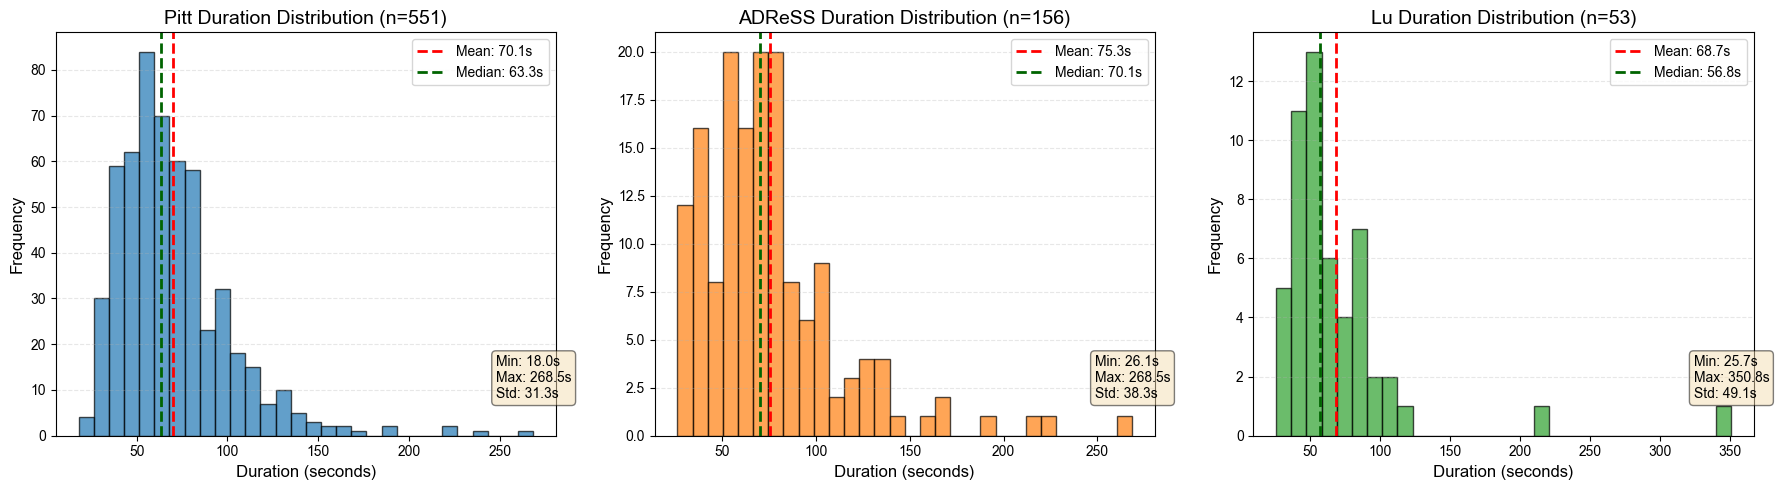

In [5]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(DATASET_NAME):
    durations = dataset_stats[name]['durations']
    ax = axes[idx]
    
    ax.hist(durations, bins=30, color=COLORS[idx], alpha=0.7, edgecolor='black')
    
    mean_val = np.mean(durations)
    median_val = np.median(durations)
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}s')
    ax.axvline(median_val, color='darkgreen', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}s')
    
    ax.set_xlabel('Duration (seconds)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{name} Duration Distribution (n={len(durations)})', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    stats_text = f'Min: {min(durations):.1f}s\nMax: {max(durations):.1f}s\nStd: {np.std(durations):.1f}s'
    ax.text(0.88, 0.2, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 6. Summary Statistics Table

In [6]:
summary_data = []
for name in DATASET_NAME:
    durations = dataset_stats[name]['durations']
    class_counts = dataset_stats[name]['class_counts']
    summary_data.append({
        'Dataset': name,
        'File Count': len(durations),
        'Dementia Count': class_counts['Dementia'],
        'Control Count': class_counts['Control'],
        'Min Duration (s)': f"{min(durations):.2f}",
        'Max Duration (s)': f"{max(durations):.2f}",
        'Mean Duration (s)': f"{np.mean(durations):.2f}",
        'Median Duration(s)': f"{np.median(durations):.2f}",
        'Total Duration (min)': f"{sum(durations)/60:.2f}"
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("Summary Statistics for All Datasets")
print("="*100)
print(df_summary.to_string(index=False))

df_summary.to_csv('audio_duration_summary.csv', index=False, encoding='utf-8-sig')


Summary Statistics for All Datasets
Dataset  File Count  Dementia Count  Control Count Min Duration (s) Max Duration (s) Mean Duration (s) Median Duration(s) Total Duration (min)
   Pitt         551             309            242            18.00           268.48             70.06              63.29               643.39
 ADReSS         156              78             78            26.06           268.48             75.30              70.05               195.78
     Lu          53              28             25            25.73           350.76             68.73              56.77                60.71
